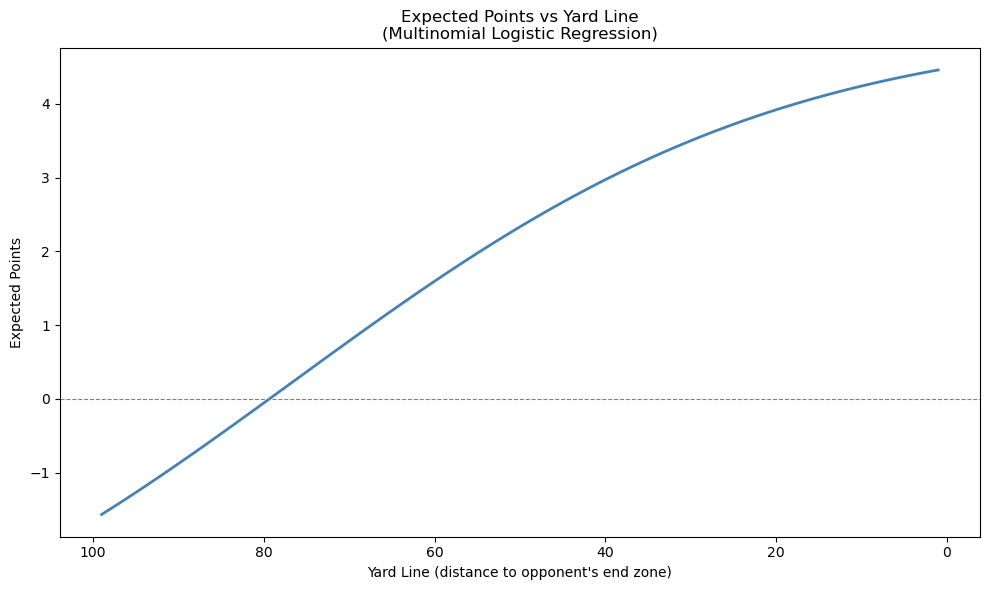

In [6]:
#T1, Q1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("05_expected-points.csv")

# Drop rows with missing values in relevant columns
df = df[["yardline_100", "pts_next_score"]].dropna()

X = df[["yardline_100"]].values
y = df["pts_next_score"].values

model = LogisticRegression(solver="lbfgs", max_iter = 2000)
model.fit(X, y)

# Predict expected points over all yard lines
yard_lines = np.arange(1, 100).reshape(-1, 1)
probs = model.predict_proba(yard_lines)
classes = model.classes_

expected_points = probs @ classes.astype(float)

plt.figure(figsize=(10, 6))
plt.plot(yard_lines, expected_points, color="steelblue", linewidth=2)
plt.xlabel("Yard Line (distance to opponent's end zone)")
plt.ylabel("Expected Points")
plt.title("Expected Points vs Yard Line\n(Multinomial Logistic Regression)")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.gca().invert_xaxis()  # 100 = own goal line, 1 = opponent's
plt.tight_layout()
plt.show()


#Implausibility: Expected points grows approximately linearly with ydl; that doesn't make sense because EP should grow very aggressively before plateauing at some number near 0.

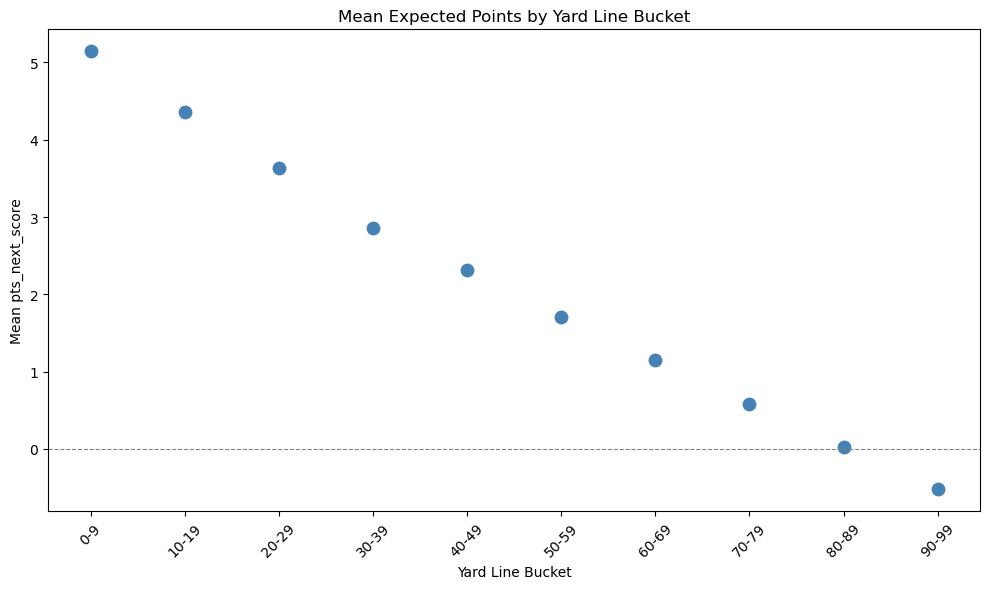

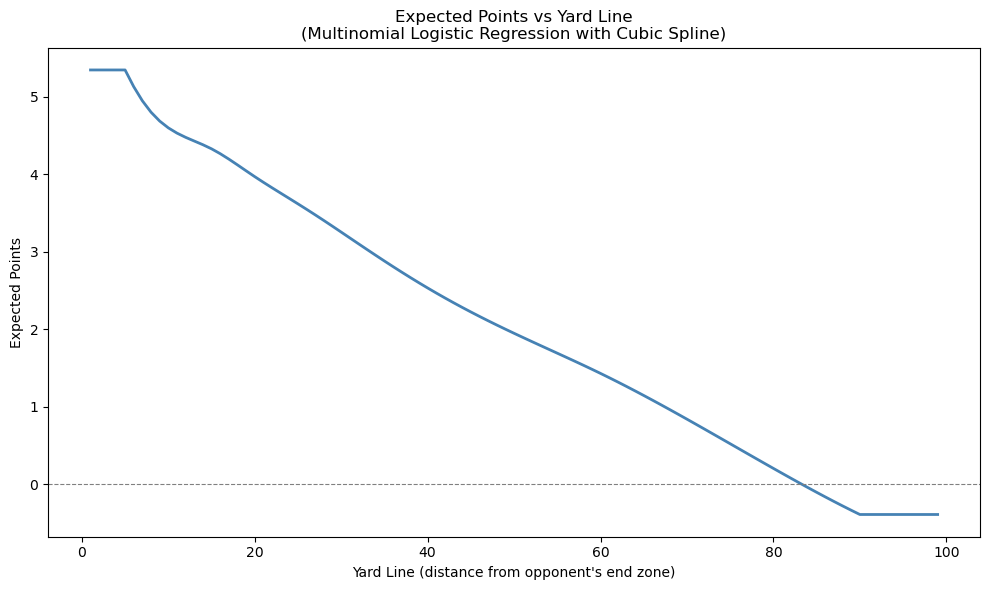

In [24]:
#T1 Q2

#Visualization
bins = list(range(0, 101, 10))
labels = [f"{i}-{i+9}" for i in range(0, 100, 10)]
df["ydl_bucket"] = pd.cut(df["yardline_100"], bins=bins, labels=labels, right=False)

bucket_means = df.groupby("ydl_bucket", observed=True)["pts_next_score"].mean()

plt.figure(figsize=(10, 6))
plt.scatter(range(len(bucket_means)), bucket_means.values, color="steelblue", s=80)
plt.xticks(range(len(bucket_means)), bucket_means.index, rotation=45)
plt.xlabel("Yard Line Bucket")
plt.ylabel("Mean pts_next_score")
plt.title("Mean Expected Points by Yard Line Bucket")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

####Spline

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import SplineTransformer

X = df[["yardline_100"]].values
y = df["pts_next_score"].values

spline = SplineTransformer(n_knots=8, degree=3, knots=[[5], [15], [20], [30], [60], [90]])
X_spline = spline.fit_transform(X)

model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_spline, y)

yard_lines = np.arange(1, 100).reshape(-1, 1)
X_pred = spline.transform(yard_lines)
probs = model.predict_proba(X_pred)
expected_points = probs @ model.classes_.astype(float)

plt.figure(figsize=(10, 6))
plt.plot(yard_lines, expected_points, color="steelblue", linewidth=2)
plt.xlabel("Yard Line (distance from opponent's end zone)")
plt.ylabel("Expected Points")
plt.title("Expected Points vs Yard Line\n(Multinomial Logistic Regression with Cubic Spline)")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

#I think the spline improves on the linear model because it captures flatness at tail-end distances, and aggressive EP growth between 45yds and 10 yds.

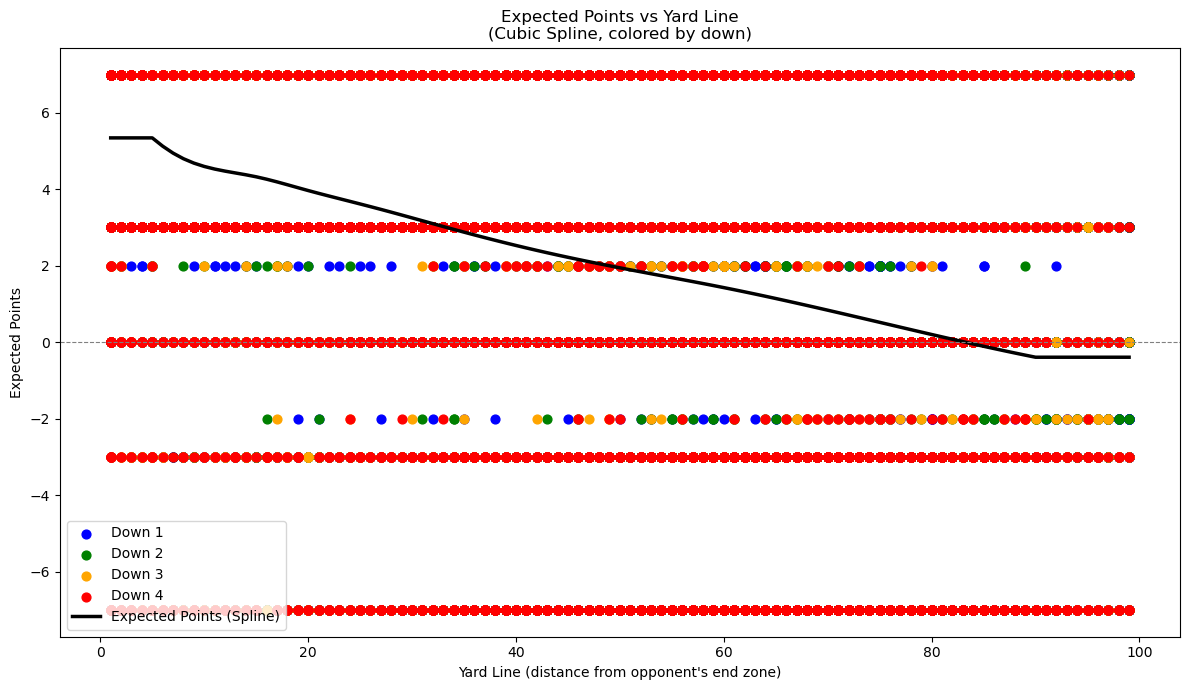

In [30]:
#T1 Q3

#Plot of E(P) vs YDL (spline) with coloring of downs
df = pd.read_csv("05_expected-points.csv")
df = df[["yardline_100", "pts_next_score", "down"]].dropna()

X = df[["yardline_100"]].values
y = df["pts_next_score"].values

spline = SplineTransformer(n_knots=8, degree=3, knots=[[5], [15], [20], [30], [60], [90]])
X_spline = spline.fit_transform(X)

model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_spline, y)

yard_lines = np.arange(1, 100).reshape(-1, 1)
X_pred = spline.transform(yard_lines)
probs = model.predict_proba(X_pred)
expected_points = probs @ model.classes_.astype(float)

# Plot empirical points colored by down
fig, ax = plt.subplots(figsize=(12, 7))

downs = sorted(df["down"].dropna().unique())
colors = {1: "blue", 2: "green", 3: "orange", 4: "red"}

for down in downs:
    subset = df[df["down"] == down]
    ax.scatter(subset["yardline_100"], subset["pts_next_score"],
               alpha=0.05, s=5, color=colors.get(down, "gray"), label=f"Down {int(down)}")

# Plot spline EP curve on top
ax.plot(yard_lines, expected_points, color="black", linewidth=2.5, label="Expected Points (Spline)")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Yard Line (distance from opponent's end zone)")
ax.set_ylabel("Expected Points")
ax.set_title("Expected Points vs Yard Line\n(Cubic Spline, colored by down)")

# Fix legend so down markers are visible (larger, opaque)
handles, labels = ax.get_legend_handles_labels()
for h in handles[:-1]:  # all but the EP line
    h.set_alpha(1)
    h.set_sizes([40])
ax.legend(handles, labels)

plt.tight_layout()
plt.show()




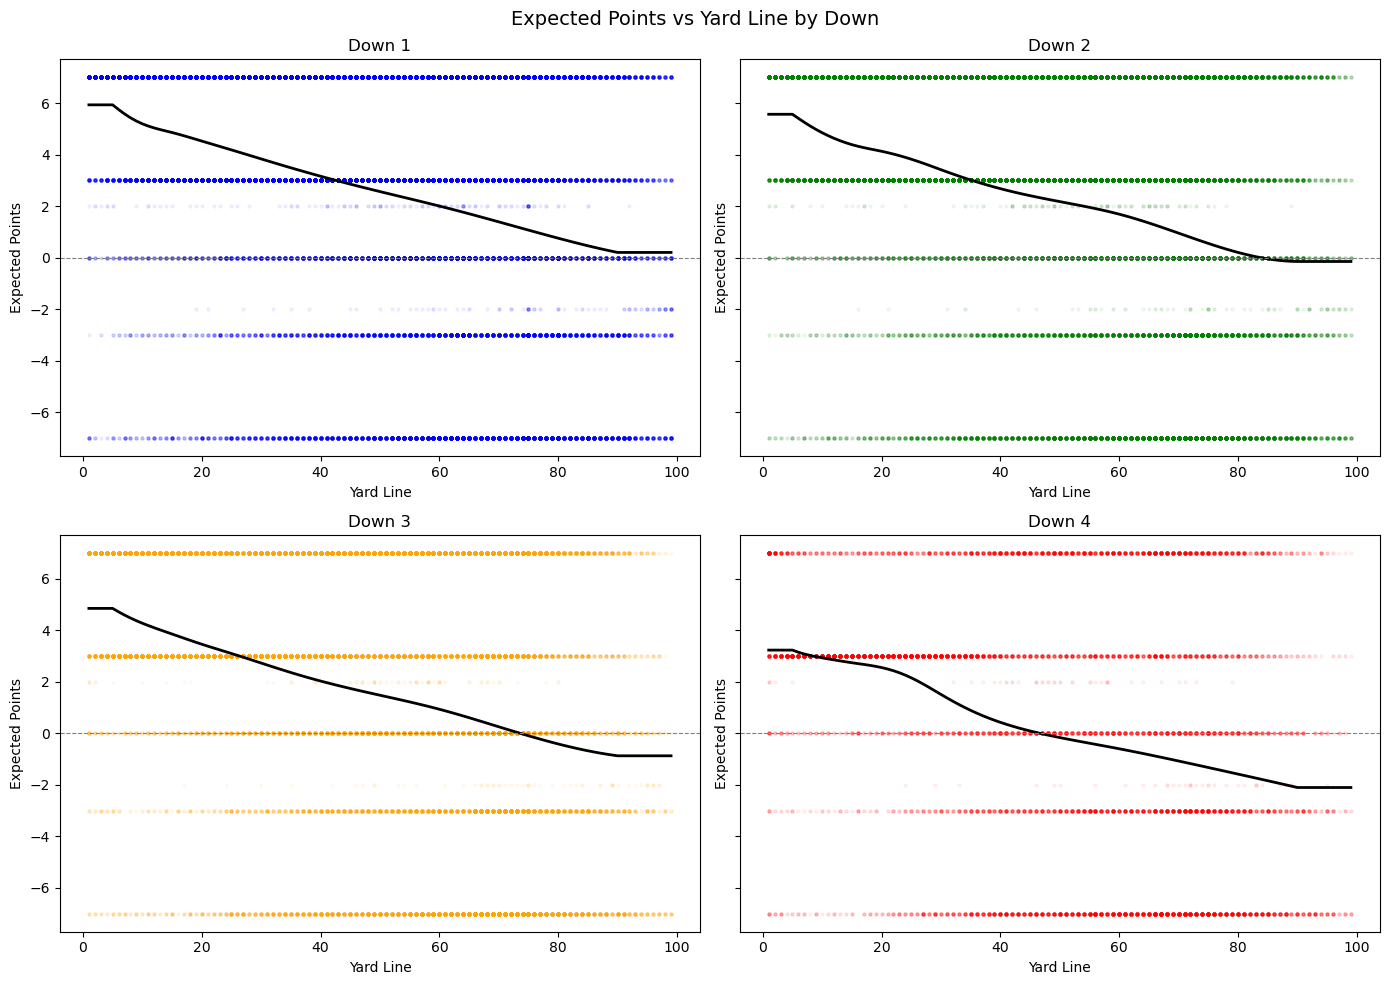

In [33]:
#T1 Q3

#Training 4 logistic regressions, each for one down

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

yard_lines = np.arange(1, 100).reshape(-1, 1)

for i, down in enumerate([1, 2, 3, 4]):
    df_down = df[df["down"] == down]
    
    X_d = df_down[["yardline_100"]].values
    y_d = df_down["pts_next_score"].values
    
    spline_d = SplineTransformer(n_knots=8, degree=3, knots=[[5], [15], [20], [30], [60], [90]])
    X_spline_d = spline_d.fit_transform(X_d)
    
    model_d = LogisticRegression(solver="lbfgs", max_iter=1000)
    model_d.fit(X_spline_d, y_d)
    
    X_pred_d = spline_d.transform(yard_lines)
    probs_d = model_d.predict_proba(X_pred_d)
    ep_d = probs_d @ model_d.classes_.astype(float)
    
    ax = axes[i]
    ax.scatter(df_down["yardline_100"], df_down["pts_next_score"],
               alpha=0.05, s=5, color=colors[down])
    ax.plot(yard_lines, ep_d, color="black", linewidth=2)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Down {down}")
    ax.set_xlabel("Yard Line")
    ax.set_ylabel("Expected Points")

plt.suptitle("Expected Points vs Yard Line by Down", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#T1 Q3

#Encoding explanation
##We want to encode each datapoint (1,2,3 or 4) into a 3-dim vector like (0,0,0), (0,0,1),etc. - depending on which down the play is on

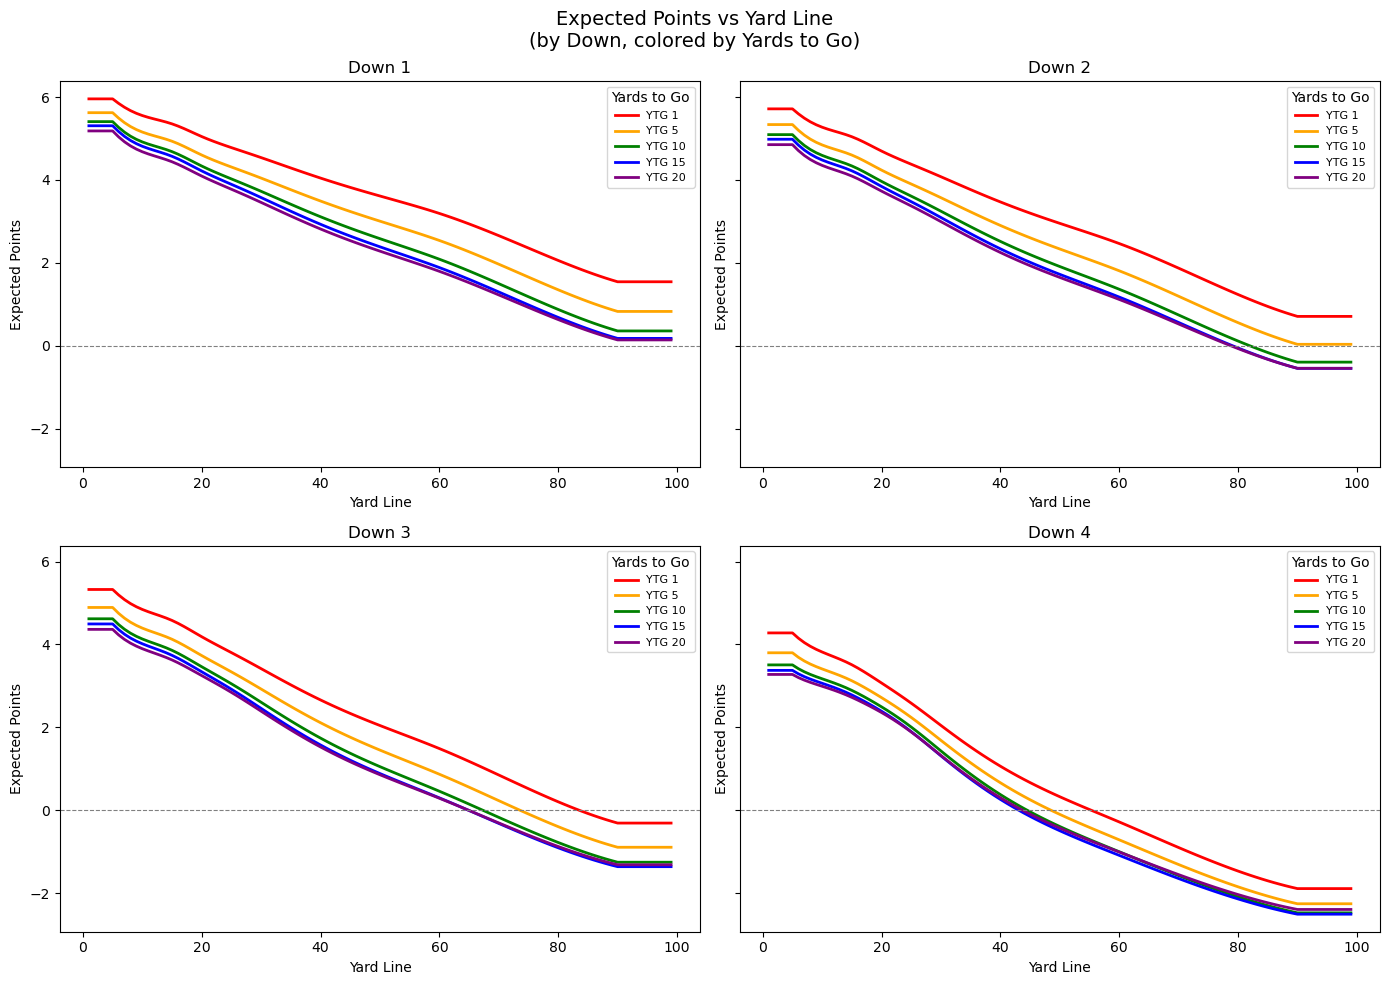

In [37]:
#T1 Q4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import SplineTransformer


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import SplineTransformer

df = pd.read_csv("05_expected-points.csv")
df = df[["yardline_100", "pts_next_score", "down", "ydstogo"]].dropna()
df = df[df["down"].isin([1, 2, 3, 4])]

# Spline on yardline
spline_ydl = SplineTransformer(n_knots=8, degree=3, knots=[[5], [15], [20], [30], [60], [90]])
X_ydl = spline_ydl.fit_transform(df[["yardline_100"]].values)

# Spline on ydstogo
spline_ytg = SplineTransformer(n_knots=4, degree=3)
X_ytg = spline_ytg.fit_transform(df[["ydstogo"]].values)

# One-hot encode down (Down 1 is baseline)
down_dummies = pd.get_dummies(df["down"], prefix="D", drop_first=True).astype(float)

# Combine all features
X = np.hstack([X_ydl, X_ytg, down_dummies.values])
y = df["pts_next_score"].values

model = LogisticRegression(solver="lbfgs", max_iter=2000)
model.fit(X, y)

# --- Plot EP vs yardline, colored by ydstogo, faceted by down ---
ydstogo_vals = [1, 5, 10, 15, 20]
colors_ytg = {1: "red", 5: "orange", 10: "green", 15: "blue", 20: "purple"}
yard_lines = np.arange(1, 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for i, down in enumerate([1, 2, 3, 4]):
    ax = axes[i]

    for ytg in ydstogo_vals:
        ydl_spline = spline_ydl.transform(yard_lines.reshape(-1, 1))
        ytg_spline = spline_ytg.transform(np.full((len(yard_lines), 1), ytg))

        down_cols = np.zeros((len(yard_lines), 3))
        if down > 1:
            down_cols[:, down - 2] = 1.0

        X_pred = np.hstack([ydl_spline, ytg_spline, down_cols])

        probs = model.predict_proba(X_pred)
        ep = probs @ model.classes_.astype(float)

        ax.plot(yard_lines, ep, color=colors_ytg[ytg], linewidth=2, label=f"YTG {ytg}")

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Down {down}")
    ax.set_xlabel("Yard Line")
    ax.set_ylabel("Expected Points")
    ax.legend(title="Yards to Go", fontsize=8)

plt.suptitle("Expected Points vs Yard Line\n(by Down, colored by Yards to Go)", fontsize=14)
plt.tight_layout()
plt.show()

#How YTG affects E(P) surface across downs
### Larger YTG drives E(P) down on any given down, which makes sense - for a given ydl, being further away from a first down reduces the odds that you eventually make it to the opponent's touchdown line, so we have to condition for that. 

##Limitation
# My view: For down i, as i increases, it should be the case that the difference in E(P) between 
## YTG 1 and YTG 20 should increase. But that difference stays constant across downs, since downs are modelled in additively.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


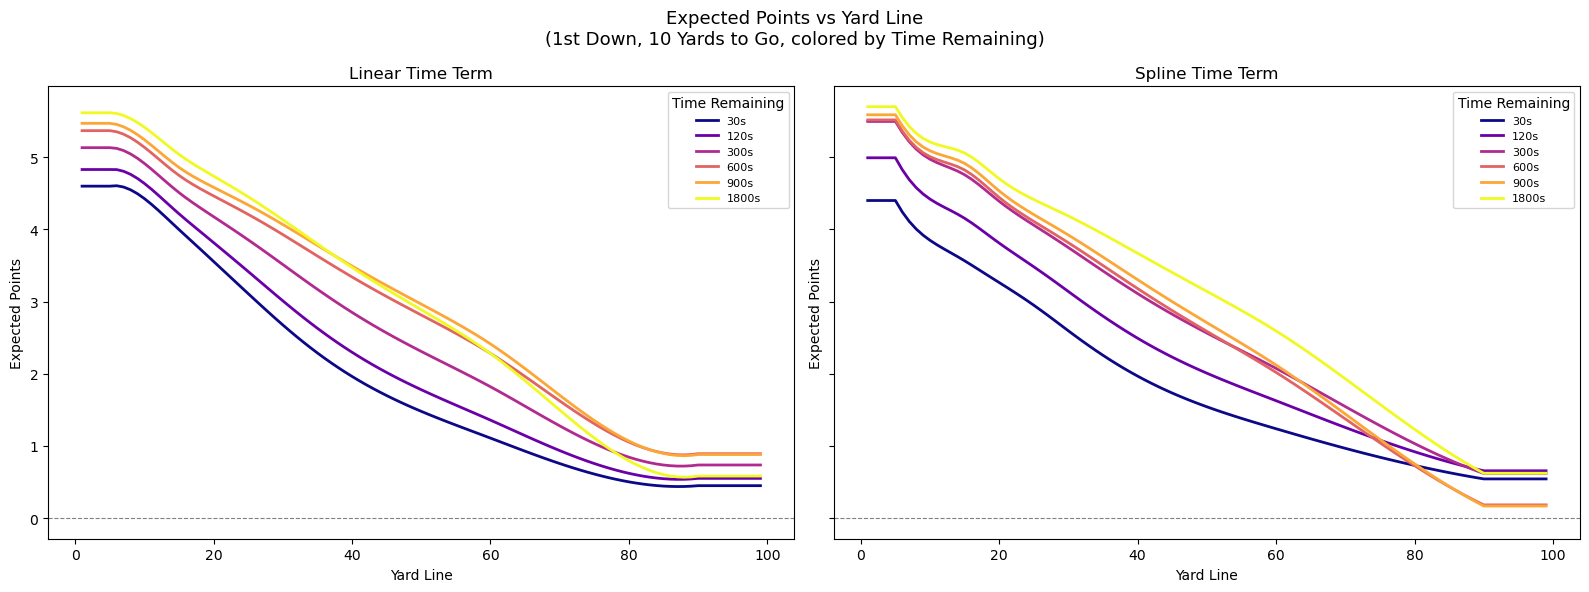

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import SplineTransformer

df = pd.read_csv("05_expected-points.csv")
df = df[["yardline_100", "pts_next_score", "down", "ydstogo", "half_seconds_remaining"]].dropna()
df = df[df["down"].isin([1, 2, 3, 4])]

# Spline on yardline
spline_ydl = SplineTransformer(n_knots=8, degree=3, knots=[[5], [15], [20], [30], [60], [90]])
X_ydl = spline_ydl.fit_transform(df[["yardline_100"]].values)

# Spline on ydstogo
spline_ytg = SplineTransformer(n_knots=4, degree=3)
X_ytg = spline_ytg.fit_transform(df[["ydstogo"]].values)

# One-hot encode down
down_dummies = pd.get_dummies(df["down"], prefix="D", drop_first=True).astype(float)

# Spline on time remaining
spline_time = SplineTransformer(n_knots=4, degree=3)
X_time_spline = spline_time.fit_transform(df[["half_seconds_remaining"]].values)

# --- Model 1: Linear time ---
X_linear = np.hstack([X_ydl, X_ytg, down_dummies.values, df[["half_seconds_remaining"]].values])
y = df["pts_next_score"].values
model_linear = LogisticRegression(solver="lbfgs", max_iter=2000)
model_linear.fit(X_linear, y)

# --- Model 2: Spline time ---
X_spline_t = np.hstack([X_ydl, X_ytg, down_dummies.values, X_time_spline])
model_spline = LogisticRegression(solver="lbfgs", max_iter=5000)
model_spline.fit(X_spline_t, y)

# --- Plotting ---
yard_lines = np.arange(1, 100)
time_vals = [30, 120, 300, 600, 900, 1800]
cmap = plt.cm.plasma
colors_time = {t: cmap(i / (len(time_vals) - 1)) for i, t in enumerate(time_vals)}

def plot_ep_by_time(ax, model, yard_lines, time_vals, use_spline_time):
    for t in time_vals:
        ydl_s = spline_ydl.transform(yard_lines.reshape(-1, 1))
        ytg_s = spline_ytg.transform(np.full((len(yard_lines), 1), 10))  # 10 yards to go
        down_cols = np.zeros((len(yard_lines), 3))  # Down 1 = baseline

        if use_spline_time:
            time_feat = spline_time.transform(np.full((len(yard_lines), 1), t))
        else:
            time_feat = np.full((len(yard_lines), 1), t)

        X_pred = np.hstack([ydl_s, ytg_s, down_cols, time_feat])
        probs = model.predict_proba(X_pred)
        ep = probs @ model.classes_.astype(float)
        ax.plot(yard_lines, ep, color=colors_time[t], linewidth=2, label=f"{t}s")

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Yard Line")
    ax.set_ylabel("Expected Points")
    ax.legend(title="Time Remaining", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

plot_ep_by_time(axes[0], model_linear, yard_lines, time_vals, use_spline_time=False)
axes[0].set_title("Linear Time Term")

plot_ep_by_time(axes[1], model_spline, yard_lines, time_vals, use_spline_time=True)
axes[1].set_title("Spline Time Term")

plt.suptitle("Expected Points vs Yard Line\n(1st Down, 10 Yards to Go, colored by Time Remaining)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#Why team quality needs to be conditioned on

##If we do not account for team quality, we won't account for the fact that good teams are overrepresented in the portion of
# the data with low ydl, and bad teams are overrepresented in the portion of the data with high ydl since they advance less per down and are
# more likely to not advance at all!